### Supplementary Fig. 33A: generalized linear model of VFC prevalence
The fitted coefficients were generated using `FigS33AB_prevalence_modeling.Rmd`.

In [1]:
import pandas as pd

df = pd.read_csv('../data/glm_coeff_vfcsize10.tsv', sep='\t')

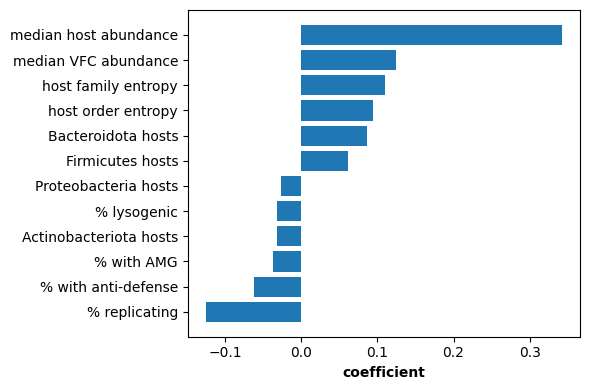

In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.barh(df['predictor'], df['coeff'])

labels = [
    "median host abundance",
    "median VFC abundance",
    "host family entropy",
    "host order entropy",
    "Bacteroidota hosts",
    "Firmicutes hosts",
    "Proteobacteria hosts",
    "% lysogenic",
    "Actinobacteriota hosts",
    "% with AMG",
    "% with anti-defense",
    "% replicating"
]

plt.xlabel('coefficient', fontweight='bold')
plt.ylabel('')
plt.yticks(ticks=range(len(df)), labels=labels)

plt.gca().invert_yaxis()
plt.tight_layout()

### Supplementary Fig. 33B: random forest regression model of VFC prevalence

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold, RandomizedSearchCV, cross_val_predict
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
from math import sqrt
from scipy.stats import pearsonr

df_vc = pd.read_excel(
    '../data/Supplementary_Data_3_VFC_metadata.xlsx',
    usecols=[
        'VFC',
        'VC_size',
        'perc_prevalence',
        'median_perc_abun',
        'primary_host_phylum', 
        'host_family_entropy', 
        'host_order_entropy', 
        'median_host_perc_abun', 
        'perc_lysogenic', 
        'perc_vOTUs_replicating',
        'perc_has_DGR',
        'perc_has_AMG',
        'perc_has_defense',
        'perc_has_antidefense'
    ]
)
df_vc1 = df_vc[df_vc.VC_size >= 10]

# -----------------------------
# 1. Features and target
# -----------------------------
target = "perc_prevalence"

features = [
    "median_perc_abun",
    "primary_host_phylum",
    "host_family_entropy",
    "host_order_entropy",
    "median_host_perc_abun",
    "perc_lysogenic",
    "perc_has_DGR",
    "perc_has_AMG",
    "perc_has_defense",
    "perc_has_antidefense",
    "perc_vOTUs_replicating"
]

X = df_vc1[features]
y = df_vc1[target]

categorical = ["primary_host_phylum"]
numeric = [col for col in features if col not in categorical]

# -----------------------------
# 2. Preprocessing
# -----------------------------
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown='ignore'), categorical),
        ("num", "passthrough", numeric)
    ]
)

# -----------------------------
# 3. Base Random Forest model
# -----------------------------
rf_base = RandomForestRegressor(
    n_estimators=1000,
    min_samples_leaf=1,
    max_features='sqrt',
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

pipeline = Pipeline([
    ("preprocess", preprocess),
    ("rf", rf_base)
])

# -----------------------------
# 4. Hyperparameter search space
# -----------------------------
param_dist = {
    "rf__min_samples_leaf": [1, 2, 3, 4, 5],
    "rf__min_samples_split": [2, 5, 10],
    "rf__max_depth": [5, 8, 10, 12, 15],
    "rf__max_features": ["sqrt", "log2", None],
    "rf__bootstrap": [True, False],
}

# -----------------------------
# 5. RandomizedSearchCV
# -----------------------------
search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_dist,
    n_iter=100,
    scoring="r2",
    cv=5,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

print("\nRunning hyperparameter search...")
search.fit(X, y)

print("\nBest hyperparameters found:")
print(search.best_params_)

# Replace pipeline with the best model
pipeline = search.best_estimator_

# -----------------------------
# 6. Cross-validation with best model
# -----------------------------
cv = KFold(n_splits=5, shuffle=True, random_state=42)

r2_scores = []
rmse_scores = []
mae_scores = []
rho_scores = []
all_importances = []

for fold, (train_idx, test_idx) in enumerate(cv.split(X), 1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    rmse = sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    rho, _ = pearsonr(y_test, y_pred)

    r2_scores.append(r2)
    rmse_scores.append(rmse)
    mae_scores.append(mae)
    rho_scores.append(rho)

    # Feature importance
    ohe = pipeline.named_steps["preprocess"].named_transformers_["cat"]
    encoded_cat_names = ohe.get_feature_names_out(categorical)
    feature_names = list(encoded_cat_names) + numeric

    importances = pipeline.named_steps["rf"].feature_importances_
    all_importances.append(importances)

# -----------------------------
# 7. Aggregate results
# -----------------------------
# Mean feature importance
mean_importance = np.mean(all_importances, axis=0)
fi_cv = pd.DataFrame({
    "feature": feature_names,
    "importance_mean": mean_importance
}).sort_values("importance_mean", ascending=False)

# Global R2
y_pred_global = cross_val_predict(pipeline, X, y, cv=cv, n_jobs=-1)
global_r2 = r2_score(y, y_pred_global)
print(f"\nGlobal % of variance explained across all folds = {global_r2*100:.1f}")


Running hyperparameter search...
Fitting 5 folds for each of 100 candidates, totalling 500 fits

Best hyperparameters found:
{'rf__min_samples_split': 2, 'rf__min_samples_leaf': 5, 'rf__max_features': 'log2', 'rf__max_depth': 8, 'rf__bootstrap': False}

Global % of variance explained across all folds = 21.0


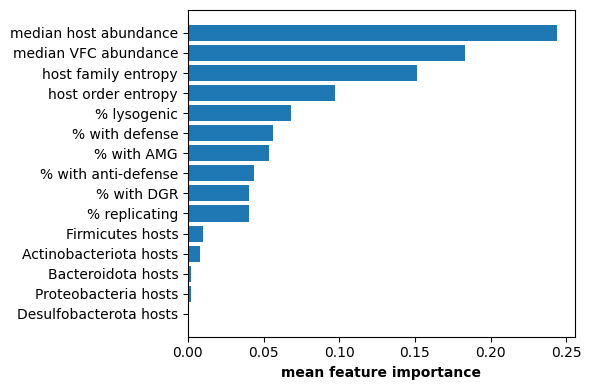

In [4]:
plt.figure(figsize=(6,4))

plt.barh(fi_cv["feature"], fi_cv["importance_mean"])

labels = [
    "median host abundance",
    "median VFC abundance",
    "host family entropy",
    "host order entropy",
    "% lysogenic",
    "% with defense",
    "% with AMG",
    "% with anti-defense",
    "% with DGR",
    "% replicating",
    "Firmicutes hosts",
    "Actinobacteriota hosts",
    "Bacteroidota hosts",
    "Proteobacteria hosts",
    "Desulfobacterota hosts"
]

plt.xlabel("mean feature importance", fontweight="bold")
plt.ylabel('')
plt.yticks(ticks=range(len(fi_cv)), labels=labels)

plt.gca().invert_yaxis()
plt.tight_layout()